In [ ]:
import torch
import torch.nn as nn
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

In [ ]:
# ==========================================
# 1. Génération des données : MULTIPLE trajectoires
# ==========================================
def lorenz_system(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    return [dx_dt, dy_dt, dz_dt]

# Paramètres de simulation
dt = 0.01
t_end = 3.0
t_eval = np.arange(0, t_end, dt)
N_t = len(t_eval)

# Conditions initiales d'entraînement (variées pour explorer l'attracteur)
train_ics = [
    [8.0, 3.0, 14.0],
    [-8.0, 7.0, 27.0],
    [1.0, 1.0, 1.0],
    [20.0, 5.0, -5.0],
    [-5.0, -10.0, 20.0],
    [15.0, -5.0, 30.0],
    [0.5, 0.5, 25.0],
    [-12.0, 12.0, 10.0],
]
N_traj = len(train_ics)

# Résolution numérique pour chaque CI
noise_level = 0.5
all_t = []       # (N_traj * N_t, 1)
all_X = []       # (N_traj * N_t, 3)
all_ic = []      # (N_traj * N_t, 3) — IC répétée pour chaque point temporel
all_X_clean = [] # sans bruit, pour visu

for ic in train_ics:
    sol = solve_ivp(lorenz_system, [0, t_end], ic, t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-10)
    X_clean = sol.y.T  # (N_t, 3)
    X_noisy = X_clean + noise_level * np.random.randn(*X_clean.shape)
    t_col = sol.t.reshape(-1, 1)
    ic_repeated = np.tile(np.array(ic).reshape(1, 3), (N_t, 1))  # (N_t, 3)
    
    all_t.append(t_col)
    all_X.append(X_noisy)
    all_ic.append(ic_repeated)
    all_X_clean.append(X_clean)

all_t = np.vstack(all_t)       # (N_traj*N_t, 1)
all_X = np.vstack(all_X)       # (N_traj*N_t, 3)
all_ic = np.vstack(all_ic)     # (N_traj*N_t, 3)
all_X_clean = np.vstack(all_X_clean)

# --- NORMALISATION ---
t_min, t_max = all_t.min(), all_t.max()
t_norm = (all_t - t_min) / (t_max - t_min)
time_scale = t_max - t_min

X_mean = all_X.mean(axis=0, keepdims=True)
X_std  = all_X.std(axis=0, keepdims=True)
X_norm = (all_X - X_mean) / X_std

# Normaliser les CI de la même façon que X
ic_norm = (all_ic - X_mean) / X_std

# Conversion en tenseurs (sur GPU si disponible)
t_tensor  = torch.tensor(t_norm, dtype=torch.float32).to(device)          # (N_total, 1)
X_tensor  = torch.tensor(X_norm, dtype=torch.float32).to(device)          # (N_total, 3)
ic_tensor = torch.tensor(ic_norm, dtype=torch.float32).to(device)         # (N_total, 3)
ic_raw_tensor = torch.tensor(all_ic, dtype=torch.float32).to(device)      # (N_total, 3) non normalisé
X_mean_t  = torch.tensor(X_mean, dtype=torch.float32).to(device)
X_std_t   = torch.tensor(X_std, dtype=torch.float32).to(device)

print(f"Nombre de trajectoires : {N_traj}")
print(f"Points par trajectoire : {N_t}")
print(f"Total points d'entraînement : {len(all_t)}")
print(f"X_mean = {X_mean.flatten()}, X_std = {X_std.flatten()}")

Nombre de trajectoires : 8
Points par trajectoire : 300
Total points d'entraînement : 2400
X_mean = [-0.91420898 -0.99225857 24.28493747], X_std = [8.31350793 9.31323062 8.45835197]


In [ ]:
# ==========================================
# 2. Architecture PINN : entrée (t, x0, y0, z0)
# ==========================================
class LorenzPINN(nn.Module):
    def __init__(self):
        super(LorenzPINN, self).__init__()
        
        # Réseau : (t_norm, x0_norm, y0_norm, z0_norm) -> (X_norm, Y_norm, Z_norm)
        # Entrée 4D, sortie 3D
        self.net = nn.Sequential(
            nn.Linear(4, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 3)
        )
        
        # Initialisation Xavier
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)
        
        # Paramètres physiques à découvrir (partagés entre toutes les trajectoires)
        self.log_sigma = nn.Parameter(torch.tensor(np.log(5.0)))
        self.log_rho   = nn.Parameter(torch.tensor(np.log(10.0)))
        self.log_beta  = nn.Parameter(torch.tensor(np.log(1.0)))
    
    @property
    def sigma(self):
        return torch.exp(self.log_sigma)
    
    @property
    def rho(self):
        return torch.exp(self.log_rho)
    
    @property
    def beta(self):
        return torch.exp(self.log_beta)

    def forward(self, t, ic):
        """
        t  : (N, 1) temps normalisé
        ic : (N, 3) condition initiale normalisée
        """
        inp = torch.cat([t, ic], dim=1)  # (N, 4)
        return self.net(inp)

    def physics_residuals(self, t, ic, X_mean, X_std, time_scale):
        """Résidus physiques pour un batch (t, ic)."""
        t = t.clone().detach().requires_grad_(True)
        X_pred_norm = self.forward(t, ic)
        
        # Dé-normaliser
        x = X_pred_norm[:, 0:1] * X_std[0, 0] + X_mean[0, 0]
        y = X_pred_norm[:, 1:2] * X_std[0, 1] + X_mean[0, 1]
        z = X_pred_norm[:, 2:3] * X_std[0, 2] + X_mean[0, 2]
        
        # Dérivées par rapport à t_norm, puis correction d'échelle
        dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0] / time_scale
        dy = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0] / time_scale
        dz = torch.autograd.grad(z, t, torch.ones_like(z), create_graph=True)[0] / time_scale
        
        # Résidus de Lorenz
        f_x = dx - self.sigma * (y - x)
        f_y = dy - (x * (self.rho - z) - y)
        f_z = dz - (x * y - self.beta * z)
        
        return f_x, f_y, f_z, X_pred_norm

model = LorenzPINN().to(device)
print(f"Paramètres initiaux : σ={model.sigma.item():.2f}, ρ={model.rho.item():.2f}, β={model.beta.item():.2f}")
print(f"Nombre de paramètres réseau : {sum(p.numel() for p in model.net.parameters())}")
print(f"Modèle sur : {next(model.parameters()).device}")

Paramètres initiaux : σ=5.00, ρ=10.00, β=1.00
Nombre de paramètres réseau : 50563


In [ ]:
# ==========================================
# 3. Boucle d'entraînement multi-trajectoires
# ==========================================

# ---- PHASE 1 : Pré-entraînement pur données ----
print("=" * 60)
print("PHASE 1 : Pré-entraînement sur les données (sans physique)")
print("=" * 60)

optimizer_pre = torch.optim.Adam(model.net.parameters(), lr=1e-3)
scheduler_pre = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pre, T_max=5000, eta_min=1e-4)

for epoch in range(5000):
    optimizer_pre.zero_grad()
    X_pred = model(t_tensor, ic_tensor)
    loss = torch.mean((X_pred - X_tensor)**2)
    loss.backward()
    optimizer_pre.step()
    scheduler_pre.step()
    if epoch % 1000 == 0:
        print(f"  Epoch {epoch:5d} | Data Loss: {loss.item():.6f}")

print(f"  Epoch final | Data Loss: {loss.item():.6f}")
print()

# ---- PHASE 2 : Entraînement PINN (données + physique progressive) ----
print("=" * 60)
print("PHASE 2 : Entraînement avec physique (curriculum)")
print("=" * 60)

epochs = 15000

optimizer_nn = torch.optim.Adam(model.net.parameters(), lr=5e-4)
optimizer_phys = torch.optim.Adam(
    [model.log_sigma, model.log_rho, model.log_beta], lr=5e-3
)
scheduler_nn = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_nn, T_max=epochs, eta_min=1e-6)
scheduler_phys = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_phys, T_max=epochs, eta_min=5e-4)

lambda_phys_min = 1e-4
lambda_phys_max = 1e-2
lambda_ic = 10.0

# Historiques
epoch_hist = []
loss_data_hist = []
loss_phys_hist = []
loss_total_hist = []
sigma_hist = []
rho_hist = []
beta_hist = []

for epoch in range(epochs):
    epoch_num = epoch + 1
    optimizer_nn.zero_grad()
    optimizer_phys.zero_grad()
    
    # Montée exponentielle de lambda_phys
    progress = min(epoch / (epochs * 0.8), 1.0)
    log_lambda = np.log(lambda_phys_min) + (np.log(lambda_phys_max) - np.log(lambda_phys_min)) * progress
    lambda_phys = np.exp(log_lambda)
    
    # Data loss (toutes trajectoires)
    X_pred_norm = model(t_tensor, ic_tensor)
    loss_data = torch.mean((X_pred_norm - X_tensor)**2)
    
    # Physics loss (on sous-échantillonne pour la vitesse)
    n_colloc = min(2000, len(t_tensor))
    idx_phys = torch.randperm(len(t_tensor), device=device)[:n_colloc]
    f_x, f_y, f_z, _ = model.physics_residuals(
        t_tensor[idx_phys], ic_tensor[idx_phys], X_mean_t, X_std_t, time_scale
    )
    loss_physics = torch.mean(f_x**2) + torch.mean(f_y**2) + torch.mean(f_z**2)
    
    # IC loss : à t=0, la sortie doit correspondre à la condition initiale
    # On sélectionne les indices t=0 pour chaque trajectoire
    t0_indices = torch.arange(0, N_traj * N_t, N_t, device=device)  # premier point de chaque traj
    t0_t = t_tensor[t0_indices]
    t0_ic = ic_tensor[t0_indices]
    X0_pred = model(t0_t, t0_ic)
    # Dé-normaliser la prédiction
    X0_pred_real = X0_pred * X_std_t + X_mean_t
    loss_ic = torch.mean((X0_pred_real - ic_raw_tensor[t0_indices])**2)
    
    loss = loss_data + lambda_phys * loss_physics + lambda_ic * loss_ic
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    
    optimizer_nn.step()
    optimizer_phys.step()
    scheduler_nn.step()
    scheduler_phys.step()
    
    epoch_hist.append(epoch_num)
    loss_data_hist.append(loss_data.item())
    loss_phys_hist.append(loss_physics.item())
    loss_total_hist.append(loss.item())
    sigma_hist.append(model.sigma.item())
    rho_hist.append(model.rho.item())
    beta_hist.append(model.beta.item())
    
    if epoch % 2000 == 0:
        print(f"  Epoch {epoch:5d} | Loss: {loss.item():.4f} | Data: {loss_data.item():.6f} | "
              f"Phys: {loss_physics.item():.2f} | IC: {loss_ic.item():.4f} | λp: {lambda_phys:.5f} | "
              f"σ={model.sigma.item():.2f} ρ={model.rho.item():.2f} β={model.beta.item():.2f}")

print()
print("=" * 60)
print(f"Vérité terrain : σ=10.00, ρ=28.00, β=2.67")
print(f"Estimations   : σ={model.sigma.item():.3f}, ρ={model.rho.item():.3f}, β={model.beta.item():.3f}")
err_s = abs(model.sigma.item() - 10.0) / 10.0 * 100
err_r = abs(model.rho.item() - 28.0) / 28.0 * 100
err_b = abs(model.beta.item() - 8/3) / (8/3) * 100
print(f"Erreurs       : σ={err_s:.1f}%, ρ={err_r:.1f}%, β={err_b:.1f}%")
print("=" * 60)

PHASE 1 : Pré-entraînement sur les données (sans physique)
  Epoch     0 | Data Loss: 1.015868
  Epoch  1000 | Data Loss: 0.036446
  Epoch  2000 | Data Loss: 0.005866
  Epoch  3000 | Data Loss: 0.004357
  Epoch  4000 | Data Loss: 0.003872
  Epoch final | Data Loss: 0.003672

PHASE 2 : Entraînement avec physique (curriculum)
  Epoch     0 | Loss: 8.4774 | Data: 0.003672 | Phys: 24749.86 | IC: 0.5999 | λp: 0.00010 | σ=5.03 ρ=10.05 β=1.01


KeyboardInterrupt: 

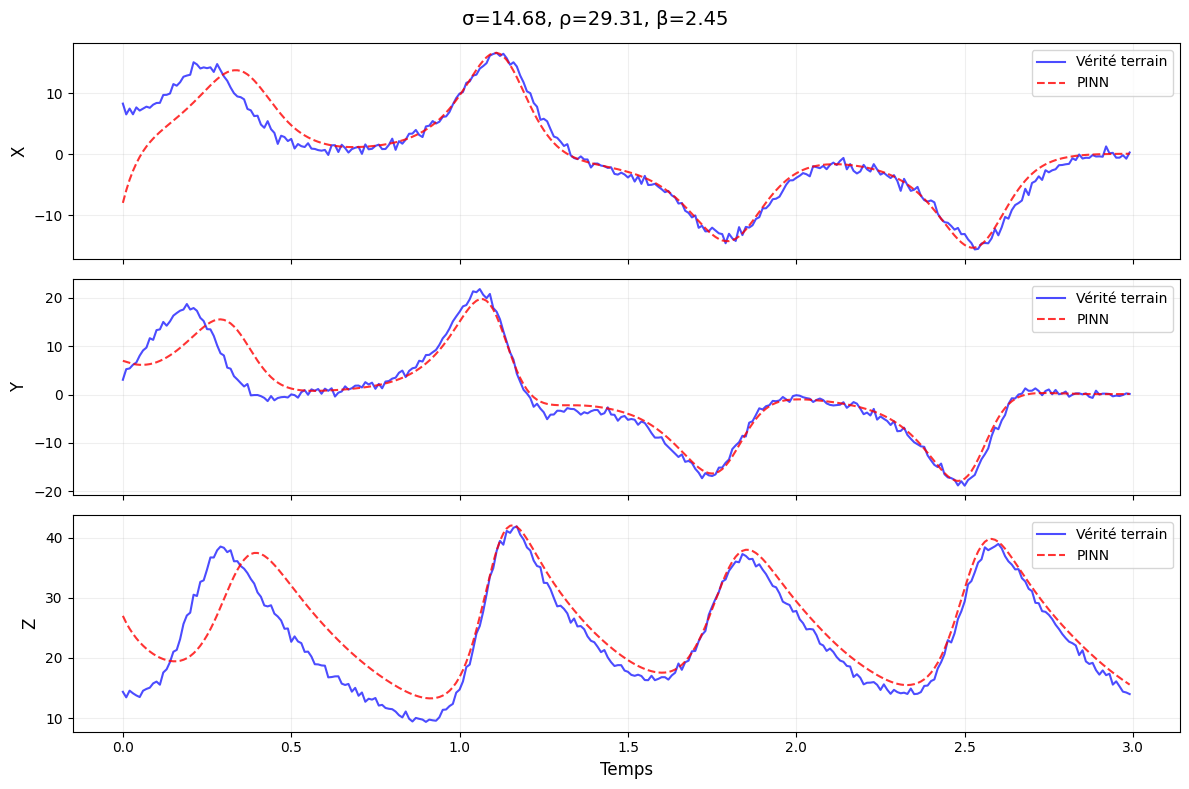

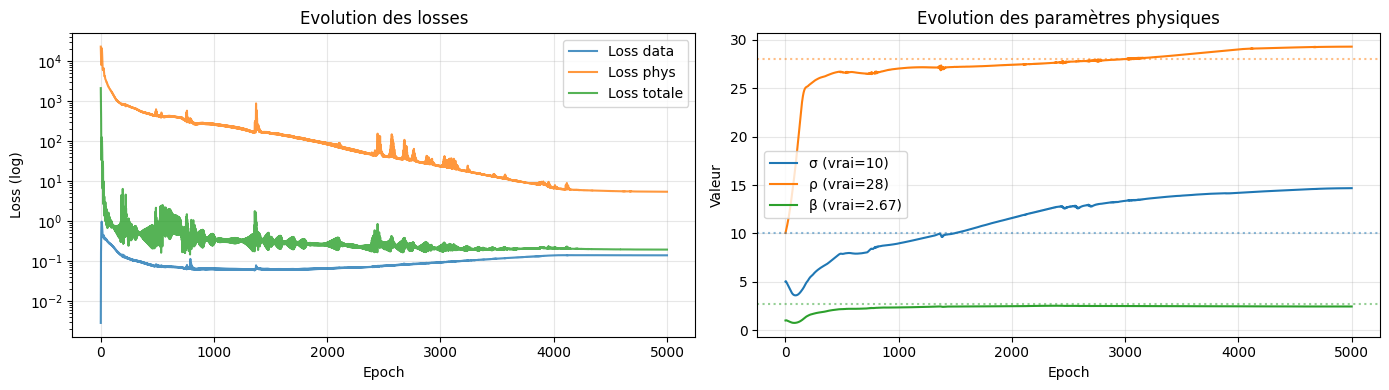

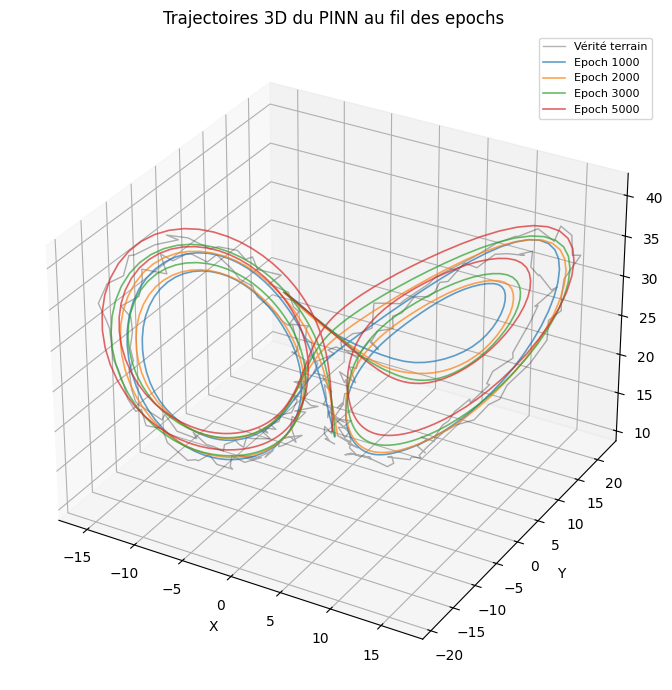

In [ ]:
# ==========================================
# 4. Visualisation des trajectoires d'entraînement
# ==========================================

# --- Trajectoires X, Y, Z pour chaque CI d'entraînement ---
n_show = min(4, N_traj)  # On montre les 4 premières
fig, axes = plt.subplots(n_show, 3, figsize=(16, 3.5 * n_show), sharex=True)
comp_labels = ['X', 'Y', 'Z']

with torch.no_grad():
    for row in range(n_show):
        start = row * N_t
        end = (row + 1) * N_t
        t_slice = t_tensor[start:end]
        ic_slice = ic_tensor[start:end]
        X_pred_norm = model(t_slice, ic_slice).cpu().numpy()
        X_pred = X_pred_norm * X_std + X_mean
        X_true = all_X[start:end]
        t_plot = all_t[start:end]
        
        for col in range(3):
            ax = axes[row, col]
            ax.plot(t_plot, X_true[:, col], 'b-', alpha=0.6, lw=1.2, label='Données (bruitées)')
            ax.plot(t_plot, X_pred[:, col], 'r--', alpha=0.8, lw=1.2, label='PINN')
            ax.grid(True, alpha=0.2)
            if row == 0:
                ax.set_title(comp_labels[col], fontsize=13, fontweight='bold')
            if row == n_show - 1:
                ax.set_xlabel('Temps', fontsize=11)
            if col == 0:
                ax.annotate(f'IC = {train_ics[row]}',
                            xy=(0.02, 0.95), xycoords='axes fraction', fontsize=8, va='top',
                            bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.7))
            if row == 0 and col == 2:
                ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    f'Trajectoires d\'entraînement — σ={model.sigma.item():.2f}, ρ={model.rho.item():.2f}, β={model.beta.item():.2f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

# --- Losses et paramètres ---
if len(epoch_hist) > 0:
    fig_loss, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    ax1.semilogy(epoch_hist, loss_data_hist, label='Loss data', alpha=0.8)
    ax1.semilogy(epoch_hist, loss_phys_hist, label='Loss phys', alpha=0.8)
    ax1.semilogy(epoch_hist, loss_total_hist, label='Loss totale', alpha=0.8)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (log)')
    ax1.set_title('Evolution des losses')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epoch_hist, sigma_hist, label='σ (vrai=10)', lw=1.5)
    ax2.plot(epoch_hist, rho_hist, label='ρ (vrai=28)', lw=1.5)
    ax2.plot(epoch_hist, beta_hist, label='β (vrai=2.67)', lw=1.5)
    ax2.axhline(y=10.0, color='C0', ls=':', alpha=0.5)
    ax2.axhline(y=28.0, color='C1', ls=':', alpha=0.5)
    ax2.axhline(y=8/3, color='C2', ls=':', alpha=0.5)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Valeur')
    ax2.set_title('Evolution des paramètres physiques')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# ==========================================
# 5. TEST : Généralisation à de NOUVELLES conditions initiales
# ==========================================
# Ces CI n'ont JAMAIS été vues pendant l'entraînement.
# Le réseau doit prédire la trajectoire correcte car il a appris
# le flot Φ(t; x0,y0,z0) du système de Lorenz.

test_ics = [
    [5.0, 5.0, 5.0],
    [-15.0, -15.0, 20.0],
    [10.0, -8.0, 35.0],
    [0.1, 0.1, 0.1],
]

t_test_eval = np.arange(0, t_end, dt)
t_test_norm = (t_test_eval.reshape(-1, 1) - t_min) / (t_max - t_min)
t_test_t = torch.tensor(t_test_norm, dtype=torch.float32).to(device)

fig, axes = plt.subplots(len(test_ics), 3, figsize=(16, 3.5 * len(test_ics)), sharex=True)
fig_3d = plt.figure(figsize=(5 * len(test_ics), 5))

rmse_list = []

for row, ic in enumerate(test_ics):
    # Vérité terrain (vrais paramètres)
    sol_true = solve_ivp(lorenz_system, [0, t_end], ic,
                         t_eval=t_test_eval, method='RK45', rtol=1e-10, atol=1e-10,
                         args=(10.0, 28.0, 8.0/3.0))
    X_true = sol_true.y.T  # (N_t, 3)
    
    # Prédiction PINN : on passe (t, ic) au réseau
    ic_arr = np.tile(np.array(ic).reshape(1, 3), (len(t_test_eval), 1))
    ic_norm_test = (ic_arr - X_mean) / X_std
    ic_test_t = torch.tensor(ic_norm_test, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        X_pred_norm = model(t_test_t, ic_test_t).cpu().numpy()
        X_pred = X_pred_norm * X_std + X_mean
    
    # RMSE
    rmse_xyz = np.sqrt(np.mean((X_true - X_pred)**2, axis=0))
    rmse_global = np.sqrt(np.mean((X_true - X_pred)**2))
    rmse_list.append((ic, rmse_xyz, rmse_global))
    
    # Tracés X, Y, Z
    for col, label in enumerate(['X', 'Y', 'Z']):
        ax = axes[row, col]
        ax.plot(t_test_eval, X_true[:, col], 'b-', lw=1.2, alpha=0.8, label='Vérité terrain')
        ax.plot(t_test_eval, X_pred[:, col], 'r--', lw=1.2, alpha=0.8, label='PINN')
        ax.grid(True, alpha=0.2)
        if row == 0:
            ax.set_title(label, fontsize=13, fontweight='bold')
        if row == len(test_ics) - 1:
            ax.set_xlabel('Temps', fontsize=11)
        if col == 0:
            ax.annotate(f'IC = {ic}\nRMSE = {rmse_global:.3f}',
                        xy=(0.02, 0.95), xycoords='axes fraction', fontsize=8, va='top',
                        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.7))
        if row == 0 and col == 2:
            ax.legend(fontsize=8, loc='upper right')

fig.suptitle(
    'TEST DE GÉNÉRALISATION — Conditions initiales JAMAIS vues\n'
    f'σ_est={model.sigma.item():.2f}, ρ_est={model.rho.item():.2f}, β_est={model.beta.item():.2f}  '
    f'(vrais : σ=10, ρ=28, β=2.67)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# --- Vue 3D ---
fig_3d, axes_3d = plt.subplots(1, len(test_ics),
                                figsize=(5 * len(test_ics), 5),
                                subplot_kw={'projection': '3d'})
for idx, ic in enumerate(test_ics):
    sol_true = solve_ivp(lorenz_system, [0, t_end], ic,
                         t_eval=t_test_eval, method='RK45', rtol=1e-10, atol=1e-10,
                         args=(10.0, 28.0, 8.0/3.0))
    ic_arr = np.tile(np.array(ic).reshape(1, 3), (len(t_test_eval), 1))
    ic_norm_test = (ic_arr - X_mean) / X_std
    ic_test_t = torch.tensor(ic_norm_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        X_pred = (model(t_test_t, ic_test_t).cpu().numpy()) * X_std + X_mean

    ax = axes_3d[idx]
    ax.plot(sol_true.y[0], sol_true.y[1], sol_true.y[2], 'b-', alpha=0.5, lw=0.8, label='Vrai')
    ax.plot(X_pred[:, 0], X_pred[:, 1], X_pred[:, 2], 'r--', alpha=0.7, lw=0.8, label='PINN')
    ax.scatter(*ic, color='green', s=40, zorder=5, label='CI')
    ax.set_xlabel('X', fontsize=8)
    ax.set_ylabel('Y', fontsize=8)
    ax.set_zlabel('Z', fontsize=8)
    ax.set_title(f'IC={ic}', fontsize=9)
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

fig_3d.suptitle('Attracteurs 3D — Test sur CI inédites', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Résumé
print("=" * 65)
print("Résumé RMSE sur les trajectoires de TEST (CI jamais vues)")
print("=" * 65)
print(f"{'CI':<25} {'RMSE_X':>8} {'RMSE_Y':>8} {'RMSE_Z':>8} {'RMSE':>8}")
print("-" * 65)
for ic, rmse_xyz, rmse_global in rmse_list:
    print(f"{str(ic):<25} {rmse_xyz[0]:8.3f} {rmse_xyz[1]:8.3f} {rmse_xyz[2]:8.3f} {rmse_global:8.3f}")
print("-" * 65)